# Phase 8: Concept Bottleneck Model

Phase 8 trains an interpretable-by-design model:

```text
image -> predicted concepts -> class
```

AwA2 provides class-level semantic attributes, so this notebook uses those attributes as concept supervision for every image in the corresponding class. This is weaker than image-level concept annotation, but it is enough to test the Concept Bottleneck workflow and to compare it against saliency maps and TCAV.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import csv
import subprocess
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

CANDIDATE_MANIFESTS = [
    PROJECT_ROOT / 'data' / 'AWA2_subset_background20' / 'awa2_manifest_subset.csv',
    PROJECT_ROOT / 'data' / 'AWA2' / 'awa2_manifest_debug.csv',
    PROJECT_ROOT / 'data' / 'AWA2' / 'awa2_manifest.csv',
]
MANIFEST = next((path for path in CANDIDATE_MANIFESTS if path.exists()), None)
if MANIFEST is None:
    raise FileNotFoundError('No AwA2 manifest found.')

METADATA_ROOT = PROJECT_ROOT / 'data' / 'AWA2'
BACKBONE_CHECKPOINT = PROJECT_ROOT / 'outputs' / 'checkpoints' / 'best_resnet50_awa2.pt'

CONCEPTS = []  # leave empty to include key concepts plus the most variable AwA2 attributes
TOP_CONCEPTS = 20
EPOCHS = 5
BATCH_SIZE = 16

CHECKPOINT_OUTPUT = PROJECT_ROOT / 'outputs' / 'checkpoints' / 'phase8_cbm_notebook.pt'
HISTORY_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_history_notebook.csv'
CONCEPT_METRICS_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_metrics_notebook.csv'
PREDICTIONS_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_cbm_predictions_notebook.csv'
INTERVENTIONS_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase8_concept_interventions_notebook.csv'
TRAINING_FIGURE = PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_cbm_training_notebook.png'
CONCEPT_FIGURE = PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_concept_prediction_metrics_notebook.png'
INTERVENTION_FIGURE = PROJECT_ROOT / 'outputs' / 'figures' / 'phase8_concept_interventions_notebook.png'

print('manifest:', MANIFEST)
print('metadata_root:', METADATA_ROOT)
print('backbone_checkpoint:', BACKBONE_CHECKPOINT, 'exists=', BACKBONE_CHECKPOINT.exists())
print('concepts:', CONCEPTS or f'auto top {TOP_CONCEPTS}')


manifest: /home/ely-01/DeepLearning/project/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
metadata_root: /home/ely-01/DeepLearning/project/Deep_Learning_XAI/data/AWA2
backbone_checkpoint: /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt exists= True
concepts: auto top 20


## Train the Bottleneck Model

This cell trains a ResNet-based CBM initialized from the Phase 2 classifier backbone when that checkpoint is available. The classifier head receives only predicted concept probabilities, so later cells can intervene directly on the concept vector.


In [2]:
cmd = [
    sys.executable,
    str(PROJECT_ROOT / 'scripts' / 'run_phase8_cbm.py'),
    '--manifest', str(MANIFEST),
    '--metadata-root', str(METADATA_ROOT),
    '--backbone-checkpoint', str(BACKBONE_CHECKPOINT),
    '--checkpoint-output', str(CHECKPOINT_OUTPUT),
    '--history-output', str(HISTORY_CSV),
    '--concept-metrics-output', str(CONCEPT_METRICS_CSV),
    '--predictions-output', str(PREDICTIONS_CSV),
    '--intervention-output', str(INTERVENTIONS_CSV),
    '--training-figure-output', str(TRAINING_FIGURE),
    '--concept-figure-output', str(CONCEPT_FIGURE),
    '--intervention-figure-output', str(INTERVENTION_FIGURE),
    '--top-concepts', str(TOP_CONCEPTS),
    '--epochs', str(EPOCHS),
    '--batch-size', str(BATCH_SIZE),
]
if CONCEPTS:
    cmd.extend(['--concepts', *CONCEPTS])

print(' '.join(cmd))
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()


/home/ely-01/DeepLearning/project/Deep_Learning_XAI/.venv/bin/python /home/ely-01/DeepLearning/project/Deep_Learning_XAI/scripts/run_phase8_cbm.py --manifest /home/ely-01/DeepLearning/project/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv --metadata-root /home/ely-01/DeepLearning/project/Deep_Learning_XAI/data/AWA2 --backbone-checkpoint /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/checkpoints/best_resnet50_awa2.pt --checkpoint-output /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/checkpoints/phase8_cbm_notebook.pt --history-output /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/reports/phase8_cbm_history_notebook.csv --concept-metrics-output /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/reports/phase8_concept_metrics_notebook.csv --predictions-output /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/reports/phase8_cbm_predictions_notebook.csv --intervention-output /home/ely-01/DeepLearning/project

## Inspect Figures

The training curves show whether the bottleneck model learns both classes and concepts. The concept metric plot shows which concepts are predicted most reliably. The intervention plot shows which manual concept changes most affect class probabilities.


/home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/figures/phase8_cbm_training_notebook.png


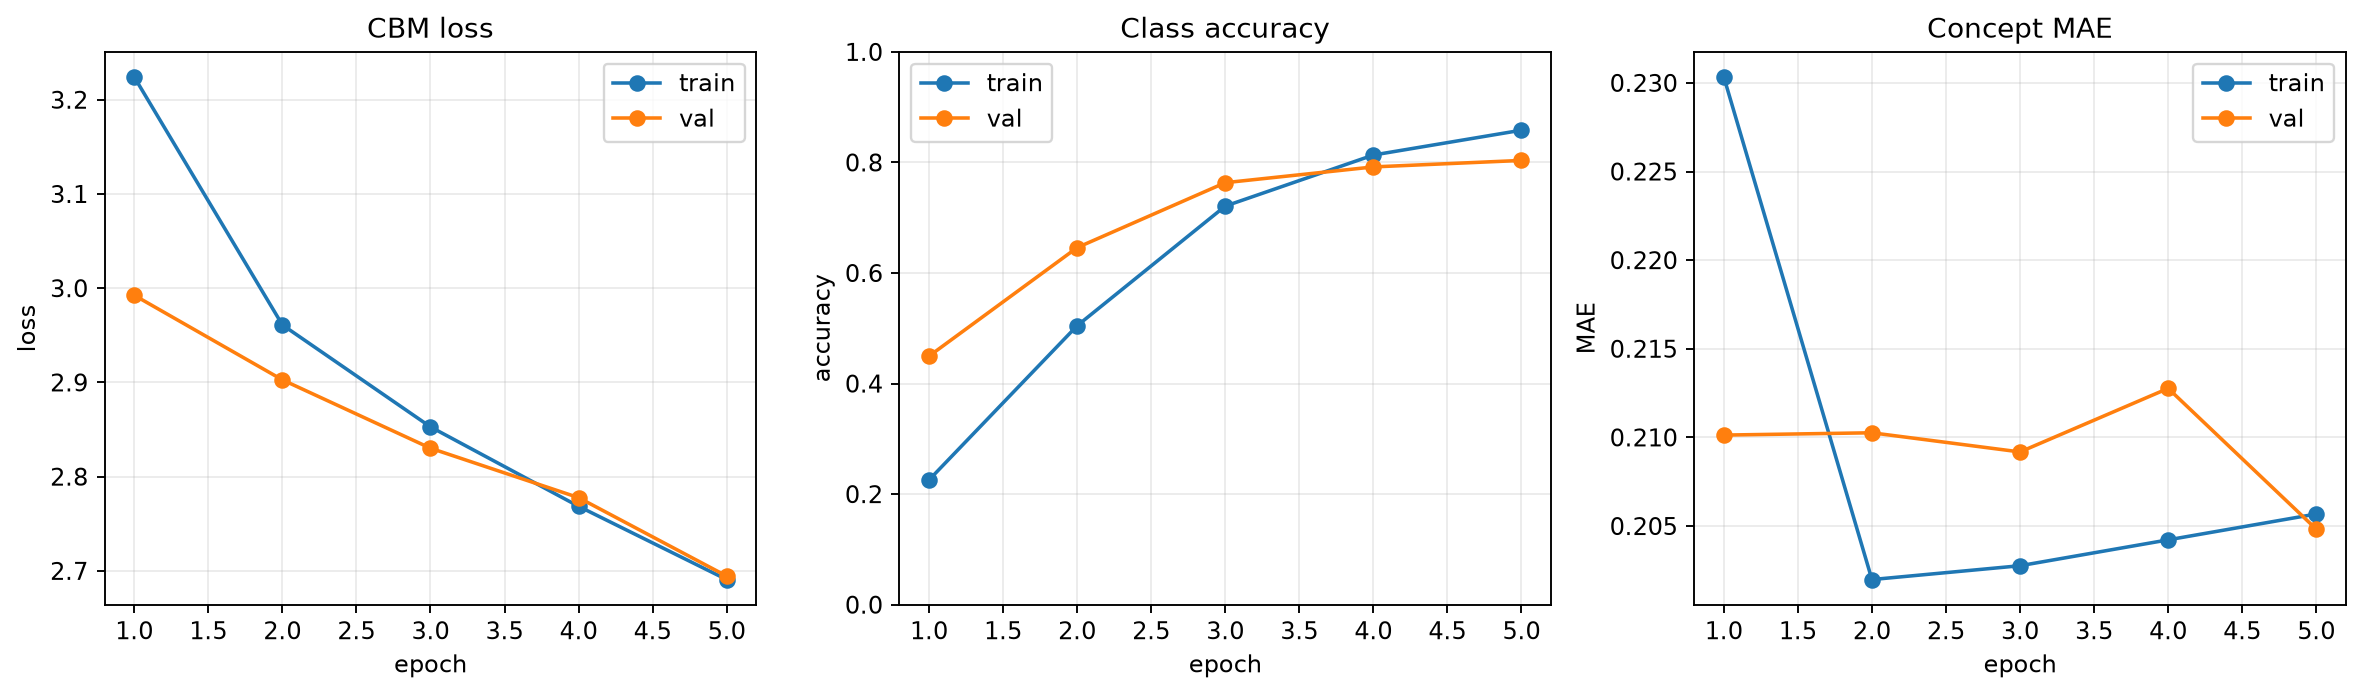

/home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/figures/phase8_concept_prediction_metrics_notebook.png


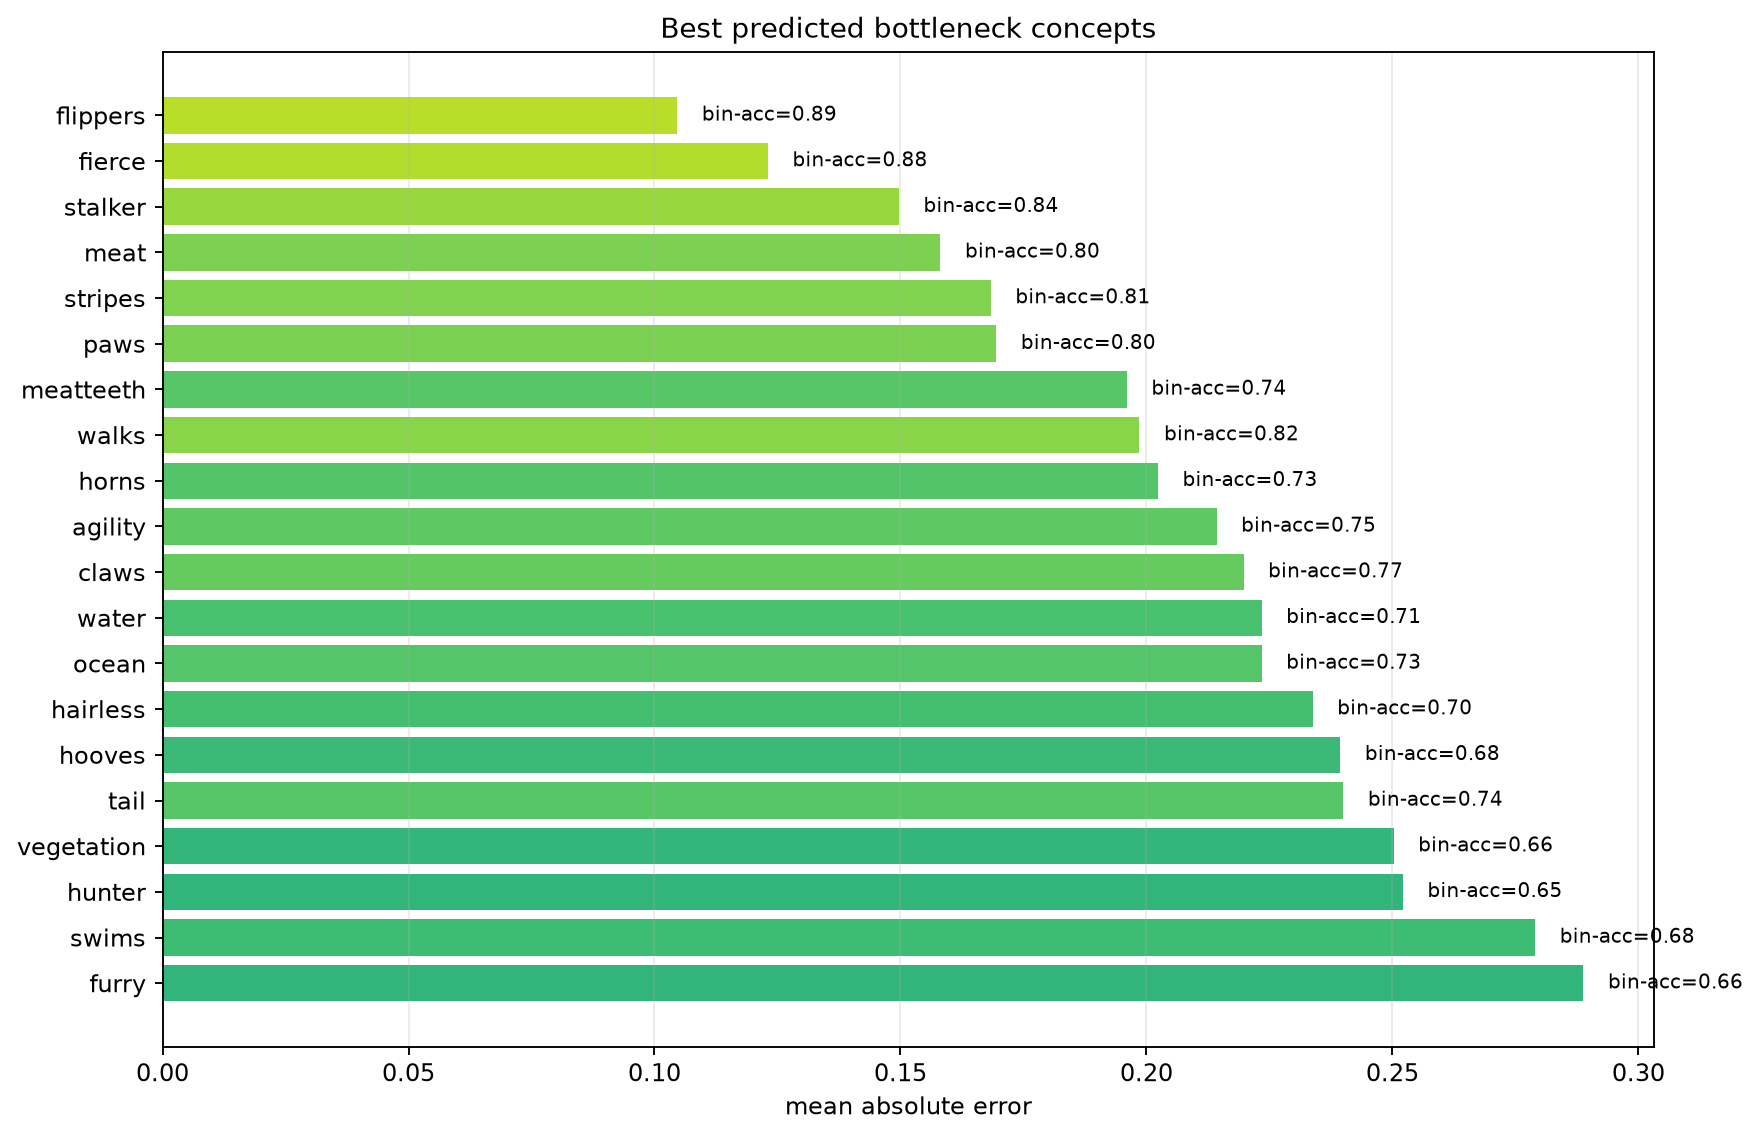

/home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/figures/phase8_concept_interventions_notebook.png


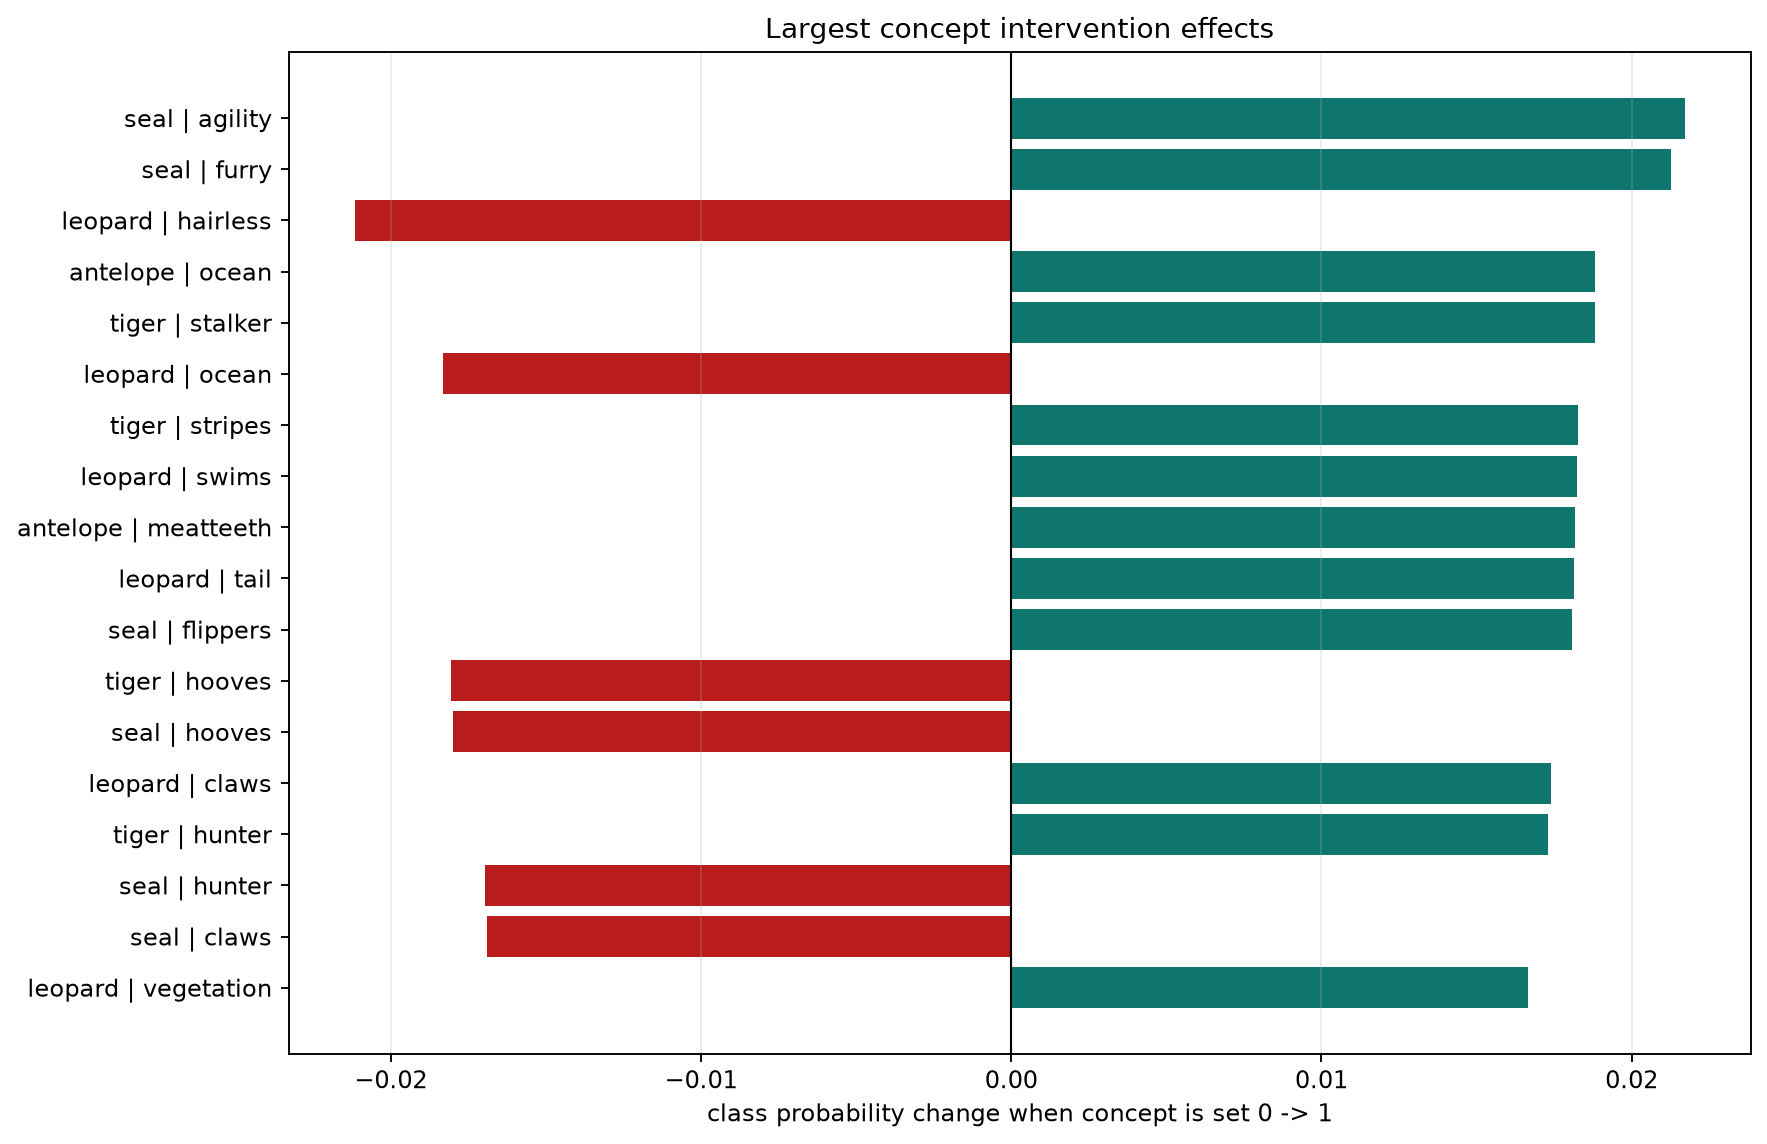

In [3]:
for figure in [TRAINING_FIGURE, CONCEPT_FIGURE, INTERVENTION_FIGURE]:
    print(figure)
    if figure.exists():
        display(Image(filename=str(figure)))
    else:
        print('missing figure:', figure)


## Inspect CSV Reports

The CSV files expose the numerical details behind the figures: training history, per-concept prediction metrics, example predictions, and intervention effects.


In [4]:
for csv_path in [HISTORY_CSV, CONCEPT_METRICS_CSV, PREDICTIONS_CSV, INTERVENTIONS_CSV]:
    print('\n', csv_path)
    if not csv_path.exists():
        print('missing csv')
        continue
    with csv_path.open('r', newline='', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    print('rows:', len(rows))
    for row in rows[:8]:
        print(row)



 /home/ely-01/DeepLearning/project/Deep_Learning_XAI/outputs/reports/phase8_cbm_history_notebook.csv
rows: 10
{'epoch': '1', 'split': 'train', 'loss': '3.224114339185395', 'class_loss': '2.734621300789883', 'concept_loss': '0.48949303813841083', 'class_acc': '0.22573687994248742', 'concept_mae': '0.2303314926811125', 'concept_binary_acc': '0.7875269590222861'}
{'epoch': '1', 'split': 'val', 'loss': '2.9924858432488155', 'class_loss': '2.4898499866459995', 'concept_loss': '0.5026358422016938', 'class_acc': '0.44966442953020136', 'concept_mae': '0.21013135622011736', 'concept_binary_acc': '0.7671979865771812'}
{'epoch': '2', 'split': 'train', 'loss': '2.9610711431263335', 'class_loss': '2.4815244460431556', 'concept_loss': '0.4795466899271923', 'class_acc': '0.5046728971962616', 'concept_mae': '0.20198088754945998', 'concept_binary_acc': '0.7792595255212078'}
{'epoch': '2', 'split': 'val', 'loss': '2.902742136244806', 'class_loss': '2.394296982144349', 'concept_loss': '0.508445150100144

## Reading the Phase

Unlike TCAV, which asks whether an existing model is sensitive to a concept direction, the CBM forces the prediction path through explicit concepts. This makes the explanation easier to inspect and intervene on, but its quality depends strongly on concept supervision. Here the labels are class-level AwA2 attributes, so the result should be presented as a first interpretable bottleneck baseline rather than a fully image-grounded concept model.
